In [27]:
import numpy as np
from scipy.integrate import odeint

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# Problem 1

Consider the Ricker model
$$x\to b x e^{-cx}$$
where $x\ge 0$, and $b,c>0$. Also Consider the Beverton-Holt model
$$x\to \frac{rx}{1+x/m}$$
where $x\ge 0$, and $r,m>0$.

Do a fixed point stability analysis for each model (all non-negative fixed points), and based upon the resulting eigenvalue expressions, discuss which generic codimension-1 bifurcations of  fixed points each model might exhibit ("might" because center manifold reduction is not required). Find parameter values wher those bifurcations occur, where possible. Optionally, consider checking your results with numerical examples. 

-----

# Problem 2

Consider the Henon map
$$\begin{pmatrix}x\\ y\end{pmatrix}\to
\begin{pmatrix}y \\ a-bx-y^2\end{pmatrix}$$
This system exhibits fold, flip, and Neimark-Sacker bifurcations. Here, you will find equations for the fold and flip bifurcations in $a\times b$ parameter space.

To do this first observe that we can state the fixed point condition as $y^2+(b+1)y-a=0$, and the fold and flip conditions can be stated in terms of Jacobian determinants, for example, for the fold bifurcation with egenvalue 1, a necessary condition is $det(J-I)=0$

1. Show that the fold bifurcation curve must satisfy the two conditions $y^2 +(b+1)y-a$ and $b+1+2y=0$ by showing that for some fixed point, $det(J-I)=0$ yields the second condition.
2. Next, to find the bifurcation curve, solve $y^2+(b+1)y-a=0$ and $b+1+2y=0$ by eliminating $y$ to show that the fold bifurcation curve is given by $a=-\frac{(1+b)^2}{4}$
3. Follow the same process but for the flip bifurcation (which has one eigenvalue with value $-1$)

-----

# Problem 3

Rossler Equations exhibit period doubling bifurcations of limit cycles. The system can be written as 
$$\begin{align}\dot x=&-y-z\\
\dot y =& x+ay\\
\dot z =&b+z(x-c)\end{align}$$

First, read the full Rössler chaotic attractor entry at http://www.scholarpedia.org/article/Rossler_attractor.

Second, numerically explore this system by plotting the following numerical solutions (illustrate these attractors by plotting the tail of trajectories which converge to them) using the parameter values associated with Figure 6 as a guide: 

1. a typical limit cycle, 
2. the limit cycle that results from the first period doubling bifurcation of the limit cycle in part a, 
3. the limit cycle that results from the 2nd period doubling bifurcation, 
4. an example of “spiral-type chaos”, and 
5. an example of “screw-type chaos”.

-----

In [64]:
x = np.linspace(-4,5,100)
y = np.linspace(-6,-1,100)
z = np.linspace(-1,6,100)

xG, yG, zG = np.meshgrid(x,y,z)

In [85]:
def Rossler(X,t,a,b,c):
    x,y,z = X
    # a,b,c = X[3:]
    
    dx = -y - z
    dy = x + a*y
    dz = b + z*(x-c)
    return [dx,dy,dz]

In [184]:
t = np.linspace(0,200,10000)
X0 = [0,0,0]

In [185]:
args = (0.4,2,4)
soln = odeint(Rossler,X0,t,args=args).T
soln.shape

(3, 10000)

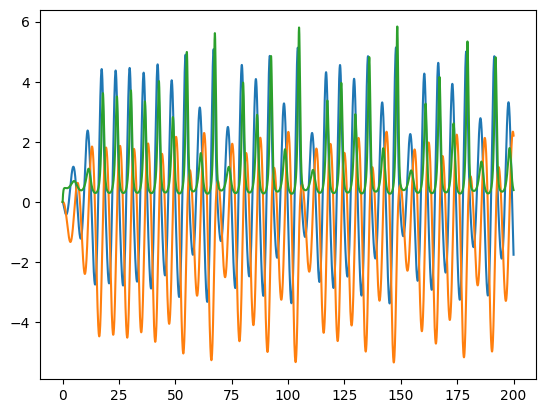

In [186]:
plt.plot(t,soln[0])
plt.plot(t,soln[1])
plt.plot(t,soln[2])

plt.show()

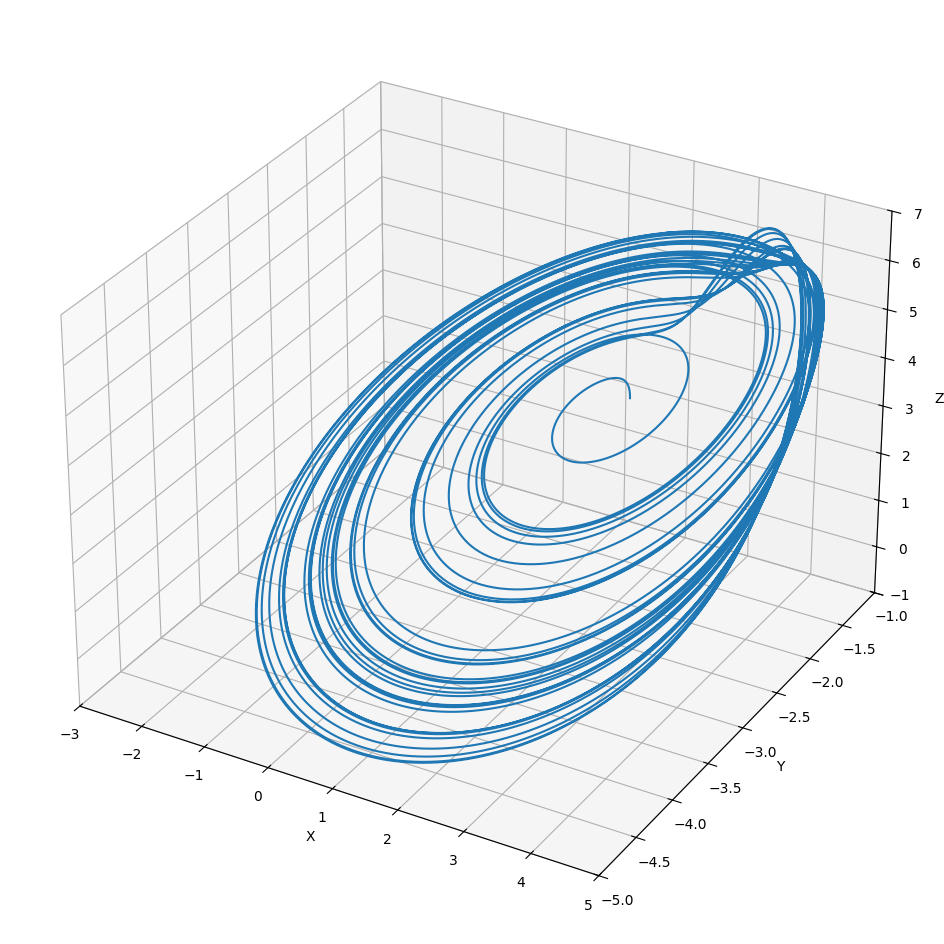

In [187]:
ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')


# Plot the 3D surface
# ax.plot_surface(X, Y, func(Xv,Yv), edgecolor='royalblue', lw=0.5, rstride=1, cstride=1,
#                 alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
# ax.contourf(Xv, Yv, func(Xv,

ax.plot(soln[0],soln[1],soln[2])

ax.set(xlim=(-3, 5), ylim=(-5, -1), zlim=(-1, 7),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()

In [ ]:
from scipy.signal import find_peaks

A = np.linspace(0.2, 0.55, 3000)
b, c = 2, 4

# Phase 1: long transient to discard (let attractor settle)
t_trans   = np.linspace(0, 500, 8000)
# Phase 2: collect steady-state data
t_collect = np.linspace(0, 300, 8000)

x0 = [0.0, -2.0, 3.0]   # single starting point; continuation carries it forward

A_plot = []
Y_plot = []

for a in A:
    # Discard transient — warm start for next iteration (continuation)
    soln_trans = odeint(Rossler, x0, t_trans, args=(a, b, c))
    x0 = soln_trans[-1]

    # Collect steady-state trajectory
    soln = odeint(Rossler, x0, t_collect, args=(a, b, c)).T
    y = soln[1]

    # Local maxima of Y reveal the attractor structure:
    #   period-1  → 1 peak, period-2 → 2 peaks, chaos → many peaks
    peaks, _ = find_peaks(y)

    A_plot.extend([a] * len(peaks))
    Y_plot.extend(y[peaks])


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(A_plot, Y_plot, marker='.', s=0.3, c='k', linewidths=0)

ax.set_xlabel(r'$a$', fontsize=13)
ax.set_ylabel(r'$Y_{\max}$ (local maxima)', fontsize=13)
ax.set_title(r'Rössler Bifurcation Diagram  $(b=2,\, c=4)$', fontsize=14)
ax.set_xlim(A[0], A[-1])

plt.tight_layout()
plt.show()


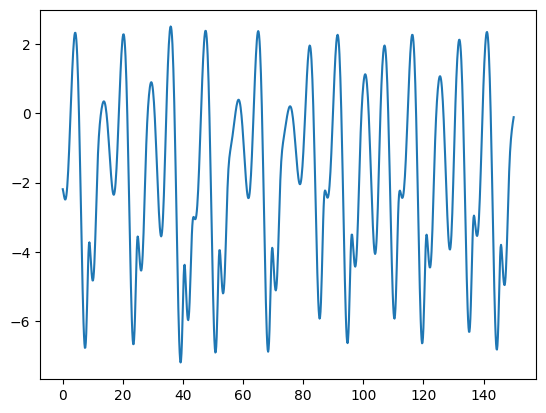

In [210]:
plt.plot(t,soln[1])